##**Sales Data Analysis**

**Dataset**: Superstore Sales Dataset

**Objective**:
Analyze business performance


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Better chart size/style
plt.style.use('ggplot')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load uploaded file
df = pd.read_csv('/content/drive/MyDrive/synent_intership/superstore2.csv', encoding='latin1')

# Preview
print(df.head())

   order_id  order_date   ship_date       ship_mode  customer_id  \
0      1684  2023-01-01  2023-01-02     First Class          238   
1      1559  2023-01-02  2023-01-03        Same Day          295   
2      1629  2023-01-03  2023-01-04  Standard Class          490   
3      1192  2023-01-04  2023-01-05     First Class          319   
4      1835  2023-01-05  2023-01-06  Standard Class          455   

  customer_name      segment        country           city state  postal_code  \
0  Chris Martin  Home Office  United States       New York    NY        18197   
1  Chris Martin  Home Office  United States  San Francisco    FL        25860   
2  Chris Martin    Corporate  United States        Chicago    TX        83000   
3    John Smith    Corporate  United States        Chicago    IL        42726   
4    John Smith     Consumer  United States    Los Angeles    NY        51396   

    region  product_id         category sub_category product_name   sales  \
0     West        1167     

In [6]:
# Check columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       500 non-null    int64  
 1   order_date     500 non-null    object 
 2   ship_date      500 non-null    object 
 3   ship_mode      500 non-null    object 
 4   customer_id    500 non-null    int64  
 5   customer_name  500 non-null    object 
 6   segment        500 non-null    object 
 7   country        500 non-null    object 
 8   city           500 non-null    object 
 9   state          500 non-null    object 
 10  postal_code    500 non-null    int64  
 11  region         500 non-null    object 
 12  product_id     500 non-null    int64  
 13  category       500 non-null    object 
 14  sub_category   500 non-null    object 
 15  product_name   500 non-null    object 
 16  sales          500 non-null    float64
 17  quantity       500 non-null    int64  
 18  discount  

###**Data Cleaning**

In [7]:
# Check missing values
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
country,0
city,0
state,0


In [8]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Check new shape
df.shape

(500, 20)

In [10]:
# clean column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)

# verify names
df.columns.tolist()

['order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit']

In [11]:
# Convert dates
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [12]:
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

###**Monthly Revenue Trends**

In [13]:
# create month column
df['month'] = df['order_date'].dt.to_period('M')

In [14]:
# monthly sales
monthly_sales = df.groupby('month')['sales'].sum()
monthly_sales

,sales
month,
2023-01,15237.93
2023-02,15431.52
2023-03,13797.91
2023-04,16890.80
2023-05,14308.15
2023-06,12778.05
2023-07,16300.42
2023-08,15621.38
2023-09,16147.35


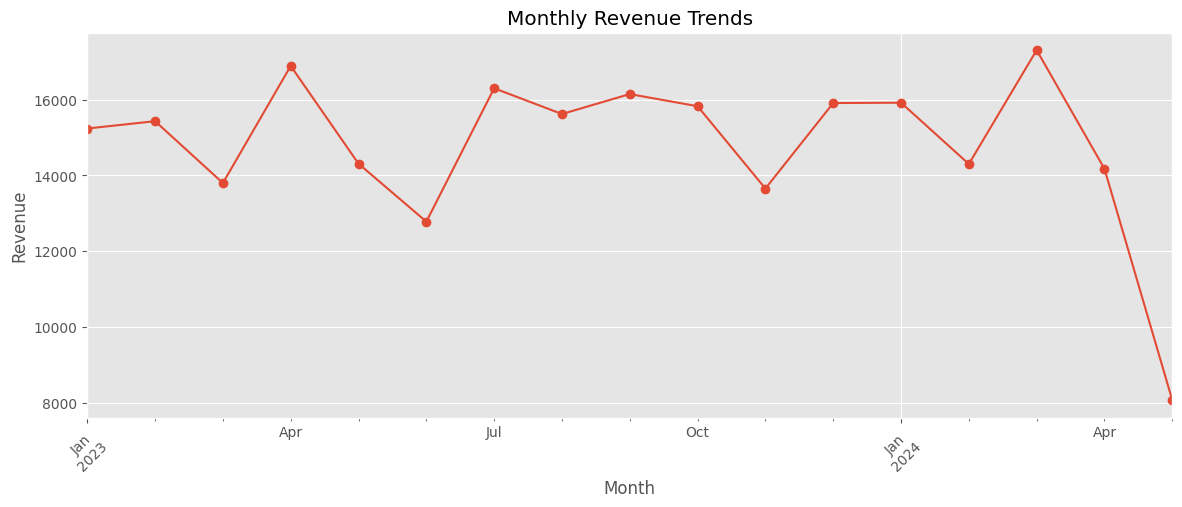

In [15]:
# Plot monthly revenue trend
# chart
plt.figure(figsize=(14,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trends")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

###**Top-Selling Products**

In [22]:
# Find top 10 products by sales
top_products = (
    df.groupby('sub_category')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,sales
sub_category,
Storage,36066.95
Chairs,35392.81
Bookcases,35387.07
Binders,32618.42
Accessories,29270.86
Phones,28936.06
Tables,28059.33
Art,25937.09


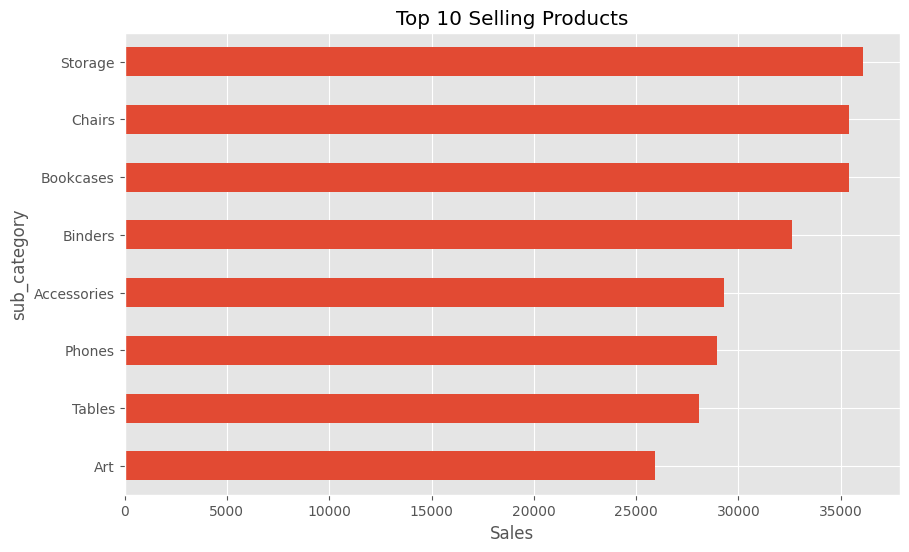

In [23]:
# Plot top products
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')
plt.title("Top 10 Selling Products")
plt.xlabel("Sales")
plt.show()

###**Profit Analysis by Region**

In [18]:
# Check if Profit column exists
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id',
       'customer_name', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'product_id', 'category', 'sub_category', 'product_name',
       'sales', 'quantity', 'discount', 'profit', 'month'],
      dtype='object')

In [19]:
region_profit = df.groupby('region')['profit'].sum()
region_profit

,profit
region,
Central,11365.16
East,13518.04
South,12416.98
West,15094.10


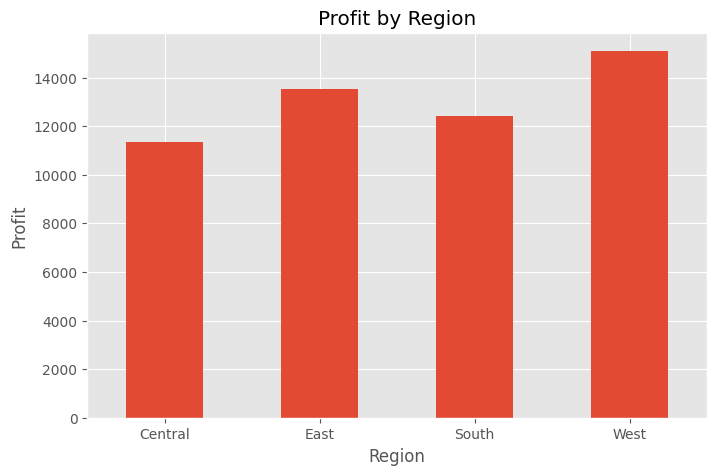

In [20]:
plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

###Discount vs Profit

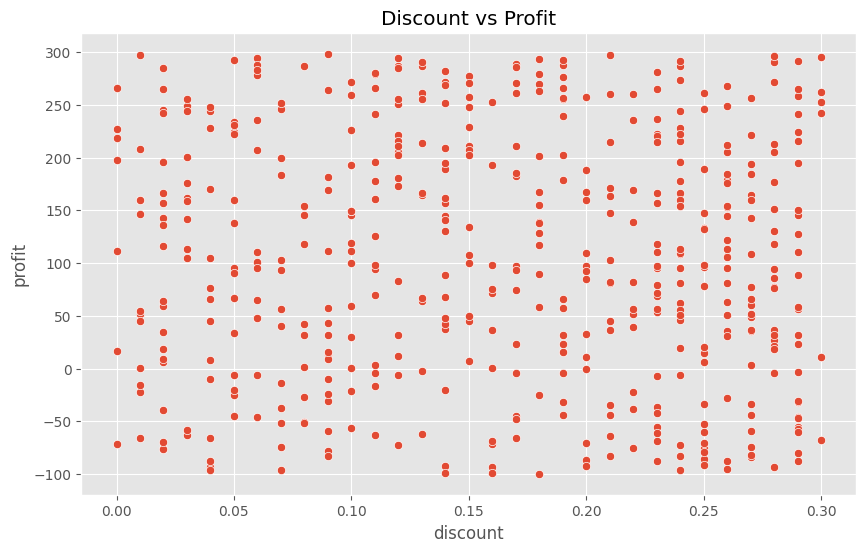

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='discount', y='profit')
plt.title("Discount vs Profit")
plt.show()

##**Business Insights Report**

1. **Monthly Revenue Trends**

  * The business performs consistently overall but experiences seasonal spikes and occasional sharp dips.

2. **Top-Selling Products** (Sub-Categories)

  * Office and furniture-related products dominate sales.
  * Storage, Chairs, and Bookcases are the strongest product lines.
  *  Art has lower demand compared to others.
  
      **Recommendation:**

      Increase promotions, inventory, and bundles for top-selling categories.
3. **Profit Analysis by Region**


*   West region generated the highest profit.
*  East region is second strongest.
*  Central region has the lowest profit.
*  Profit gap between West and Central is significant.






Strengths

* Consistent monthly sales
* Strong furniture and office supply demand
* West region highly profitable

Weak Areas

* Sudden revenue drop in May 2024
* Central region underperforming
* Some categories contribute less revenue

Final Recommendations

* Focus on West region strategies and replicate them elsewhere.
* Improve Central region profitability through campaigns and pricing.
* Increase stock for Storage, Chairs, Bookcases.
* Investigate reason for May 2024 revenue drop.
* Promote low-selling categories like Art.

In [24]:
df.to_csv('superstore_cleaned.csv', index=False)